# CVRP code walkthrough with RL4CO

The mathematical formulation is covered in the tutorial slides. Here we use the
official [RL4CO repository](https://github.com/ai4co/rl4co) to inspect its concrete
implementation: environment state, transition, feasibility mask, decoder rollout,
reward, and POMO multi-start. The policy was pretrained on synthetic CVRP15
instances generated by RL4CO; this notebook focuses on the coding path rather than
running the training loop.


In [3]:
# Run once if RL4CO is not installed in the active kernel:
# %pip install -q "rl4co==0.6.0"

from __future__ import annotations

from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch

try:
    from IPython.display import display
except ImportError:
    display = print
from rl4co.envs.routing import CVRPEnv, CVRPTWEnv
from rl4co.models import POMO
from rl4co.utils.decoding import process_logits
from rl4co.utils.ops import unbatchify

torch.manual_seed(1234)
torch.set_grad_enabled(False)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

# Optional: set CVRP_EXPORT_DIR to save the figures used in the slides.
EXPORT_DIR = os.environ.get("CVRP_EXPORT_DIR")
if EXPORT_DIR:
    Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)


def finish_figure(fig: plt.Figure, name: str) -> None:
    fig.tight_layout()
    if EXPORT_DIR:
        fig.savefig(Path(EXPORT_DIR) / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()


def instance_values(td, raw_capacity):
    """Return CPU tensors and demands in the original CVRP units."""
    item = td[0].detach().cpu()
    locs = item["locs"]
    capacity = float(raw_capacity)
    demands = torch.cat((torch.zeros(1), item["demand"] * capacity))
    return item, locs, demands, capacity


def plot_instance(td, raw_capacity, ax=None, title="CVRP instance"):
    _, locs, demands, capacity = instance_values(td, raw_capacity)
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 5.4))

    ax.scatter(
        locs[1:, 0],
        locs[1:, 1],
        s=115,
        facecolor="#DDEEFF",
        edgecolor="#286090",
        linewidth=1.5,
    )
    ax.scatter(
        locs[0, 0],
        locs[0, 1],
        s=190,
        marker="s",
        facecolor="#F8D34F",
        edgecolor="#3A3A3A",
        linewidth=1.5,
    )
    for node, (x, y) in enumerate(locs):
        label = "D" if node == 0 else f"{node}\nq={int(demands[node])}"
        ax.text(x, y + 0.035, label, ha="center", va="bottom", fontsize=8)

    ax.set_title(f"{title}   (Q={capacity:.0f})", loc="left")
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
    ax.set_aspect("equal")
    return ax


def split_routes(actions: torch.Tensor) -> list[list[int]]:
    sequence = [0, *actions.detach().cpu().tolist(), 0]
    routes, route = [], [0]
    for node in sequence[1:]:
        route.append(int(node))
        if node == 0:
            if len(route) > 2:
                routes.append(route)
            route = [0]
    if len(route) > 1:
        routes.append(route + [0])
    return routes


def plot_solution(td, actions, raw_capacity, reward=None, ax=None, title="Constructed solution"):
    _, locs, demands, _ = instance_values(td, raw_capacity)
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 5.4))

    colors = ["#3D8DFF", "#F2994A", "#27AE60", "#9B51E0", "#EB5757"]
    for route_id, route in enumerate(split_routes(actions)):
        path = locs[route]
        ax.plot(
            path[:, 0],
            path[:, 1],
            marker="o",
            linewidth=2.1,
            markersize=4,
            color=colors[route_id % len(colors)],
            label=f"vehicle {route_id + 1}",
        )

    ax.scatter(
        locs[0, 0],
        locs[0, 1],
        s=190,
        marker="s",
        facecolor="#F8D34F",
        edgecolor="#3A3A3A",
        zorder=5,
    )
    for node, (x, y) in enumerate(locs):
        label = "D" if node == 0 else f"{node}\nq={int(demands[node])}"
        ax.text(x, y + 0.035, label, ha="center", va="bottom", fontsize=8)

    suffix = "" if reward is None else f" | length={-float(reward):.3f}"
    ax.set_title(f"{title}{suffix}", loc="left")
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
    ax.set_aspect("equal")
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    return ax


## 1. Instance and MDP environment

`CVRPEnv` stores the instance and dynamic construction state in a `TensorDict`.
Below we inspect those tensors and execute one transition with `env.step`.


,node,type,x,y,demand
0,0,depot,0.328,0.746,0
1,1,customer,0.478,0.185,8
2,2,customer,0.558,0.315,2
3,3,customer,0.853,0.496,8
4,4,customer,0.598,0.563,7
5,5,customer,0.795,0.370,7
6,6,customer,0.398,0.096,9
7,7,customer,0.320,0.703,7
8,8,customer,0.456,0.389,4
9,9,customer,0.914,0.879,4


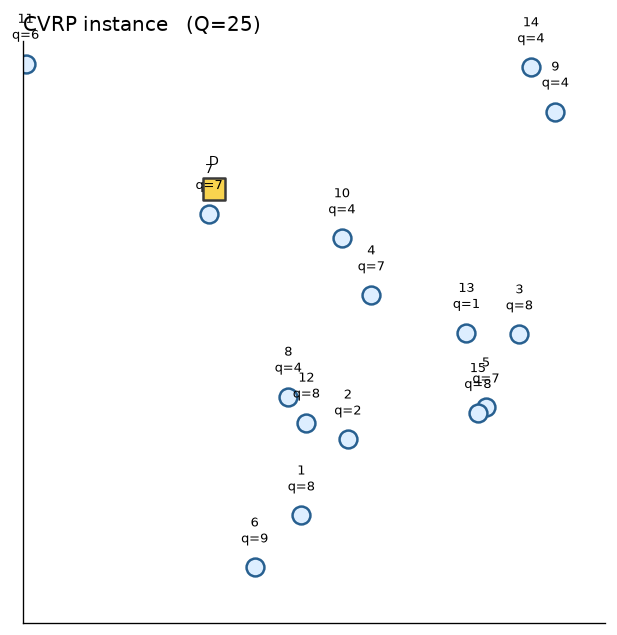

In [4]:
CVRP_CAPACITY = 25.0
env = CVRPEnv(generator_params={"num_loc": 15, "capacity": CVRP_CAPACITY})
td0 = env.reset(batch_size=[1])

raw_capacity = float(env.generator.capacity)
_, locs, demands, capacity = instance_values(td0, raw_capacity)
instance_table = pd.DataFrame(
    {
        "node": range(len(locs)),
        "type": ["depot", *(["customer"] * (len(locs) - 1))],
        "x": locs[:, 0].numpy().round(3),
        "y": locs[:, 1].numpy().round(3),
        "demand": demands.numpy().astype(int),
    }
)
display(instance_table)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
plot_instance(td0, raw_capacity, ax=ax)
finish_figure(fig, "01-rl4co-instance")


In [5]:
first_action = int(torch.where(td0["action_mask"][0, 1:])[0][0] + 1)
td1 = td0.clone()
td1["action"] = torch.tensor([first_action])
td1 = env.step(td1)["next"]

state_table = pd.DataFrame(
    [
        {"state": "current_node", "before": 0, "after": int(td1["current_node"].item())},
        {
            "state": "used_capacity (original units)",
            "before": float(td0["used_capacity"].item()) * capacity,
            "after": float(td1["used_capacity"].item()) * capacity,
        },
        {
            "state": "visited_customers",
            "before": int(td0["visited"][..., 1:].sum()),
            "after": int(td1["visited"][..., 1:].sum()),
        },
    ]
)
display(state_table)


,state,before,after
0,current_node,0.0,1.0
1,used_capacity (original units),0.0,8.0
2,visited_customers,0.0,1.0


## 2. Feasibility mask

In RL4CO, `action_mask=True` means **feasible**. Visited customers and demands
exceeding the remaining capacity are removed before action selection. RL4CO stores
capacity internally on a normalized 0–1 scale; the outputs below convert it back to
the original demand units used in the instance.


In [6]:
td_mask = td0.clone()
customer_demands = td_mask["demand"][0]
largest = int(customer_demands.argmax() + 1)
smallest = int(customer_demands.argmin() + 1)
remaining = customer_demands.clone()
remaining[[largest - 1, smallest - 1]] = -1
second_largest = int(remaining.argmax() + 1)
selected = [largest, smallest, second_largest]

for action in selected:
    assert bool(td_mask["action_mask"][0, action]), f"node {action} is infeasible"
    td_mask["action"] = torch.tensor([action])
    td_mask = env.step(td_mask)["next"]

remaining_capacity_normalized = float(
    td_mask["vehicle_capacity"].item() - td_mask["used_capacity"].item()
)
remaining_capacity = remaining_capacity_normalized * capacity
used_capacity = capacity - remaining_capacity
feasible = td_mask["action_mask"][0].detach().cpu()
visited = td_mask["visited"][0].bool().detach().cpu()
capacity_infeasible = (~feasible) & (~visited)
capacity_infeasible[0] = False  # depot is governed by a separate routing rule
assert capacity_infeasible.any(), "demo state has no capacity-infeasible customer"

mask_table = pd.DataFrame(
    {
        "node": range(len(locs)),
        "demand": demands.numpy().astype(int),
        "visited": visited.numpy(),
        "feasible": feasible.numpy(),
    }
)

print("Partial route:", [0, *selected])
print(f"Used capacity: {used_capacity:.0f} / {capacity:.0f}")
print(f"Remaining capacity: {remaining_capacity:.0f} / {capacity:.0f}")
display(mask_table)


Partial route: [0, 6, 13, 1]
Used capacity: 18 / 25
Remaining capacity: 7 / 25


,node,demand,visited,feasible
0,0,0,False,True
1,1,8,True,False
2,2,2,False,True
3,3,8,False,False
4,4,7,False,True
5,5,7,False,True
6,6,9,True,False
7,7,7,False,True
8,8,4,False,True
9,9,4,False,True


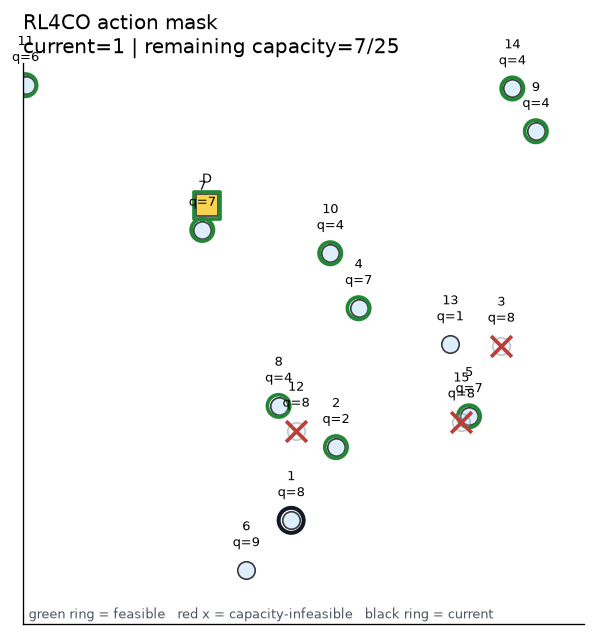

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))

for node, (x, y) in enumerate(locs):
    is_depot = node == 0
    marker = "s" if is_depot else "o"
    facecolor = "#F8D34F" if is_depot else "#DDEEFF"
    alpha = 1.0 if feasible[node] or visited[node] else 0.28
    ax.scatter(
        x,
        y,
        s=175 if is_depot else 110,
        marker=marker,
        facecolor=facecolor,
        edgecolor="#3A3A3A",
        alpha=alpha,
    )
    if feasible[node]:
        ax.scatter(
            x,
            y,
            s=255 if is_depot else 180,
            marker=marker,
            facecolor="none",
            edgecolor="#238636",
            linewidth=2.2,
        )
    elif capacity_infeasible[node]:
        ax.scatter(x, y, s=155, marker="x", color="#C13C37", linewidth=2.2)
    if node == int(td_mask["current_node"].item()):
        ax.scatter(
            x,
            y,
            s=300 if is_depot else 225,
            marker=marker,
            facecolor="none",
            edgecolor="#111827",
            linewidth=2.4,
        )

    label = "D" if is_depot else f"{node}\nq={int(demands[node])}"
    ax.text(x, y + 0.035, label, ha="center", va="bottom", fontsize=8)

ax.set_title(
    "RL4CO action mask\n"
    f"current={int(td_mask['current_node'].item())} | "
    f"remaining capacity={remaining_capacity:.0f}/{capacity:.0f}",
    loc="left",
)
ax.text(
    0.01,
    0.01,
    "green ring = feasible   red x = capacity-infeasible   black ring = current",
    transform=ax.transAxes,
    fontsize=8,
    color="#4B5563",
)
ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[])
ax.set_aspect("equal")
finish_figure(fig, "02-rl4co-mask")


## 3. Decoder and constructive rollout

The policy encodes the instance once, then repeats logits → mask → action →
environment step. Before the softmax, infeasible logits are masked to `-inf`;
therefore every infeasible node receives exactly zero probability. We expose one
decoder step before running the complete constructive rollout.


Loaded pretrained policy: /Users/jremmerden/Library/CloudStorage/OneDrive-TUEindhoven/Tutorial IJCAI/jssp_tutorial 2/drl-co-tutorial/tutorials/cvrp/checkpoints/pomo-cvrp15-standard/pomo_cvrp15_policy.pt
Probability assigned to infeasible nodes: 0.0


/opt/homebrew/Caskroom/miniforge/base/envs/test_jssp_remove_all/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/opt/homebrew/Caskroom/miniforge/base/envs/test_jssp_remove_all/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


,node,feasible,probability
2,2,True,0.8782
8,8,True,0.1216
0,0,True,0.0000
1,1,False,0.0000
3,3,False,0.0000
4,4,True,0.0000
5,5,True,0.0000
6,6,False,0.0000
7,7,True,0.0000
9,9,True,0.0000


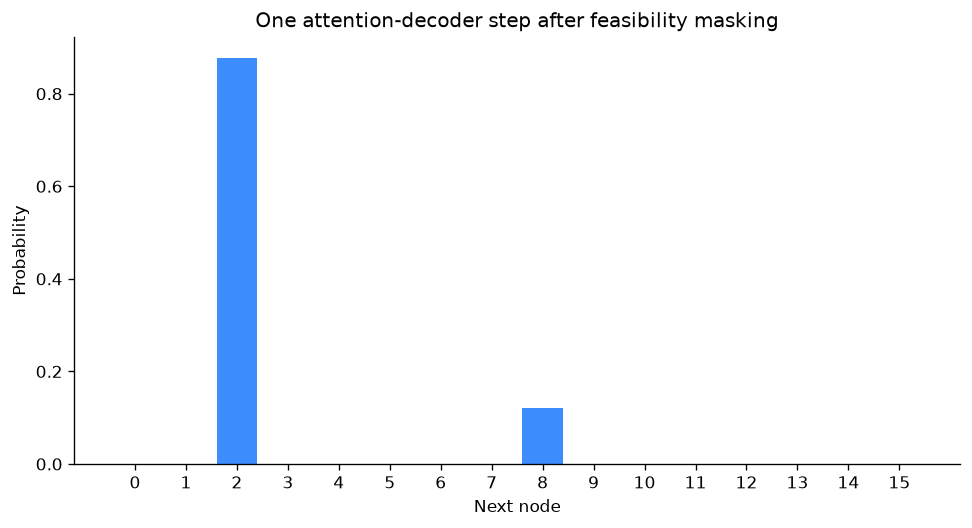

In [8]:
pomo = POMO(
    env,
    policy_kwargs={"embed_dim": 128, "num_encoder_layers": 6},
    num_augment=1,
)
pomo.eval()
policy = pomo.policy

checkpoint_name = Path(
    "checkpoints/pomo-cvrp15-standard/pomo_cvrp15_policy.pt"
)

checkpoint_candidates = [
    checkpoint_name,                    # 从 notebooks 目录启动
    Path("notebooks") / checkpoint_name # 从仓库根目录启动
]

checkpoint_path = next(
    (path for path in checkpoint_candidates if path.exists()),
    None,
)

if checkpoint_path is None:
    raise FileNotFoundError(
        "Pretrained policy not found. "
        "Expected notebooks/checkpoints/pomo-cvrp15-standard/"
        "pomo_cvrp15_policy.pt"
    )

policy.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )
)

print(f"Loaded pretrained policy: {checkpoint_path.resolve()}")

hidden, _ = policy.encoder(td_mask)
td_dec, env_dec, cache = policy.decoder.pre_decoder_hook(
    td_mask.clone(), env, hidden, num_starts=0
)
logits, decoder_mask = policy.decoder(td_dec, cache, num_starts=0)
logprobs = process_logits(
    logits.clone(),
    decoder_mask,
    temperature=policy.temperature,
    tanh_clipping=policy.tanh_clipping,
    mask_logits=policy.mask_logits,
)
probabilities = logprobs.exp()[0].detach().cpu()
decoder_mask_cpu = decoder_mask[0].detach().cpu()
infeasible_probability = probabilities[~decoder_mask_cpu].sum()
assert torch.equal(probabilities[~decoder_mask_cpu], torch.zeros_like(probabilities[~decoder_mask_cpu]))
print(f"Probability assigned to infeasible nodes: {float(infeasible_probability):.1f}")

decoder_table = pd.DataFrame(
    {
        "node": range(len(probabilities)),
        "feasible": decoder_mask_cpu.numpy(),
        "probability": probabilities.numpy().round(4),
    }
).sort_values("probability", ascending=False)
display(decoder_table)

fig, ax = plt.subplots(figsize=(8.2, 4.5))
bar_colors = ["#3D8DFF" if decoder_mask_cpu[i] else "#D8D8D8" for i in range(len(decoder_mask_cpu))]
ax.bar(range(len(probabilities)), probabilities, color=bar_colors)
ax.set(
    xlabel="Next node",
    ylabel="Probability",
    title="One attention-decoder step after feasibility masking",
)
ax.set_xticks(range(len(probabilities)))
finish_figure(fig, "03-rl4co-decoder-step")


Action sequence: [14, 9, 3, 13, 4, 0, 11, 7, 0, 8, 1, 6, 2, 0, 5, 15, 12, 0, 10]
Reward: -5.772 (= negative route length)
Route length: 5.772
Feasibility check: passed


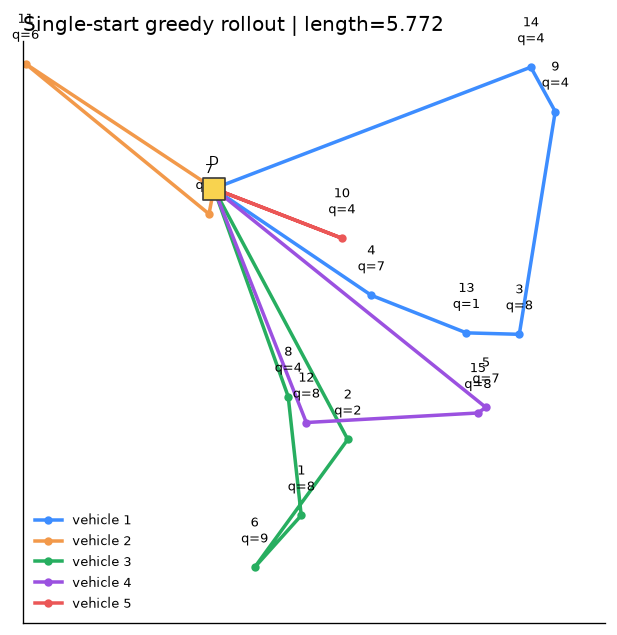

In [9]:
greedy_out = policy(
    td0.clone(),
    env,
    phase="test",
    decode_type="greedy",
    return_actions=True,
)
greedy_actions = greedy_out["actions"][0]
greedy_reward = greedy_out["reward"][0]

env.check_solution_validity(td0, greedy_out["actions"])
print("Action sequence:", greedy_actions.tolist())
print(f"Reward: {float(greedy_reward):.3f} (= negative route length)")
print(f"Route length: {-float(greedy_reward):.3f}")
print("Feasibility check: passed")

fig, ax = plt.subplots(figsize=(7.2, 5.4))
plot_solution(
    td0,
    greedy_actions,
    raw_capacity,
    reward=greedy_reward,
    ax=ax,
    title="Single-start greedy rollout",
)
finish_figure(fig, "04-rl4co-greedy-rollout")


## 4. POMO multi-start and shared reward baseline

For CVRP, RL4CO defines the trajectory reward as `R = - route_length`. POMO
constructs one trajectory per first customer. During training, their mean reward
is the shared baseline `b`, and each trajectory uses advantage `A_s = R_s - b`.
Here we inspect the same reward and baseline quantities with greedy multi-start
decoding; no optimization step is run in this notebook.


Shared baseline (mean reward): -5.743


,first_customer,reward,route_length,reward_advantage
5,6,-5.226,5.226,0.517
11,12,-5.226,5.226,0.517
0,1,-5.257,5.257,0.486
1,2,-5.747,5.747,-0.004
6,7,-5.772,5.772,-0.030
7,8,-5.772,5.772,-0.030
10,11,-5.772,5.772,-0.030
13,14,-5.772,5.772,-0.030
8,9,-5.862,5.862,-0.119
12,13,-5.867,5.867,-0.125


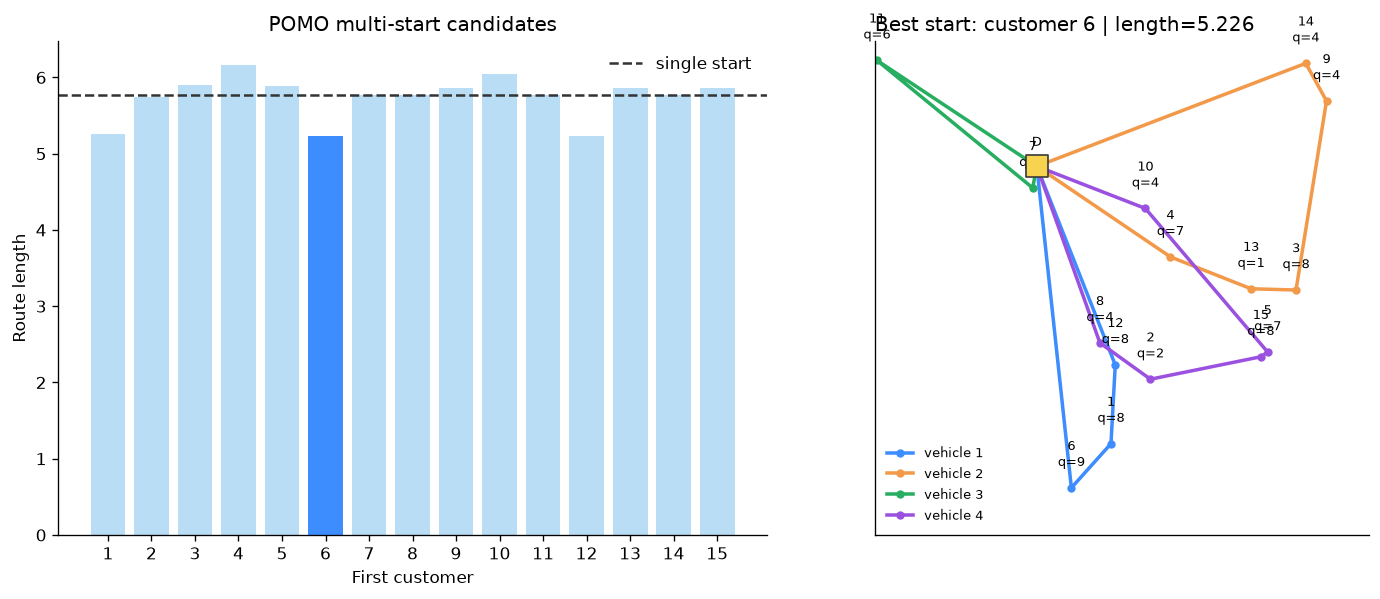

In [10]:
num_starts = env.get_num_starts(td0)
multi_out = policy(
    td0.clone(),
    env,
    phase="test",
    decode_type="multistart_greedy",
    num_starts=num_starts,
    return_actions=True,
)

multi_rewards = unbatchify(multi_out["reward"], num_starts)
multi_actions = unbatchify(multi_out["actions"], num_starts)
shared_baseline = multi_rewards.mean(dim=-1, keepdim=True)
advantages = multi_rewards - shared_baseline
first_customers = multi_actions[0, :, 0].detach().cpu()
best_start_idx = int(multi_rewards[0].argmax())
best_actions = multi_actions[0, best_start_idx]
best_reward = multi_rewards[0, best_start_idx]

env.check_solution_validity(td0, best_actions[None])

pomo_table = pd.DataFrame(
    {
        "first_customer": first_customers.numpy(),
        "reward": multi_rewards[0].detach().cpu().numpy().round(3),
        "route_length": (-multi_rewards[0]).detach().cpu().numpy().round(3),
        "reward_advantage": advantages[0].detach().cpu().numpy().round(3),
    }
)
print(f"Shared baseline (mean reward): {float(shared_baseline[0, 0]):.3f}")
display(pomo_table.sort_values("route_length"))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1))
bar_colors = [
    "#3D8DFF" if index == best_start_idx else "#B8DDF5"
    for index in range(num_starts)
]
axes[0].bar(pomo_table["first_customer"].astype(str), pomo_table["route_length"], color=bar_colors)
axes[0].axhline(
    -float(greedy_reward),
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    label="single start",
)
axes[0].set(xlabel="First customer", ylabel="Route length", title="POMO multi-start candidates")
axes[0].legend(frameon=False)

plot_solution(
    td0,
    best_actions,
    raw_capacity,
    reward=best_reward,
    ax=axes[1],
    title=f"Best start: customer {int(first_customers[best_start_idx])}",
)
finish_figure(fig, "05-rl4co-pomo-multistart")


## 5. Extending the code path: CVRPTW

CVRPTW keeps the same constructive loop, but time windows affect both the
environment and the neural policy inputs. The mask requires arrival by the window
end and the transition waits when the vehicle arrives early. In RL4CO, the node
embedding adds time windows and service duration, while the decoder context also
adds current time; the reward remains negative route length.
Consequently, a CVRP checkpoint cannot be loaded directly as a CVRPTW policy; the
matching CVRPTW architecture must be trained or adapted separately.


In [11]:
tw_env = CVRPTWEnv(generator_params={"num_loc": 15})
tw_td = tw_env.reset(batch_size=[1])

extension_table = pd.DataFrame(
    [
        {
            "component": "environment state",
            "CVRP implementation": "used_capacity, visited",
            "CVRPTW change": "add current_time, time_windows, durations",
        },
        {
            "component": "feasibility mask",
            "CVRP implementation": "unvisited and within capacity",
            "CVRPTW change": "also require arrival before window closes",
        },
        {
            "component": "state transition",
            "CVRP implementation": "update load and visited set",
            "CVRPTW change": "also update travel, waiting, and service time",
        },
        {
            "component": "node embedding",
            "CVRP implementation": "x, y, demand",
            "CVRPTW change": "add window start/end and service duration",
        },
        {
            "component": "decoder context",
            "CVRP implementation": "current node + remaining capacity",
            "CVRPTW change": "also add current time",
        },
        {
            "component": "reward",
            "CVRP implementation": "negative route length",
            "CVRPTW change": "unchanged in RL4CO 0.6.0",
        },
    ]
)
display(extension_table)
expected_tw_keys = ["current_time", "current_loc", "durations", "time_windows", "distances"]
print("Additional CVRPTW state keys:", [key for key in expected_tw_keys if key in tw_td.keys()])
print("Use a separately trained/adapted CVRPTW policy; do not directly reuse the CVRP checkpoint.")


,component,CVRP implementation,CVRPTW change
0,environment state,"used_capacity, visited","add current_time, time_windows, durations"
1,feasibility mask,unvisited and within capacity,also require arrival before window closes
2,state transition,update load and visited set,"also update travel, waiting, and service time"
3,node embedding,"x, y, demand",add window start/end and service duration
4,decoder context,current node + remaining capacity,also add current time
5,reward,negative route length,unchanged in RL4CO 0.6.0


Additional CVRPTW state keys: ['current_time', 'current_loc', 'durations', 'time_windows', 'distances']
Use a separately trained/adapted CVRPTW policy; do not directly reuse the CVRP checkpoint.


## Takeaways

- RL4CO separates the environment transition from the neural policy.
- Stepwise-decomposable hard constraints enter through dynamic state and a boolean mask; infeasible actions receive zero probability.
- CVRP reward is negative route length; POMO adds parallel starts and uses their mean reward as a shared baseline during training.
- New routing variants may change both environment logic and policy embeddings/context, requiring matching training or adaptation.
